@author Nikolay Zhabchikov

На момент исследования у нас есть 3 категории (баранина, свинина и говядина) для которых уже написаны две модели и сделаны предсказания с помощью ChatGPT и 1 категория (птица) для которой у нас есть только своим модели. За самую точную модель берем ChatGPT.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Баранина

In [2]:
mutton_df = pd.read_csv('data\monitorings_archive\Баранина.csv')
mutton_cls_df = pd.read_csv('data\categories\Баранина_разрубы.csv', sep=';')

In [3]:
mutton_df = mutton_df.rename(columns={'Категория': 'model_1', 'Новая Категория':'model_2', 'Конечная категория':'gpt'})
mutton_df['gpt'] = mutton_df['gpt'].str.lower()

In [4]:
mutton_df.head(1)

,Наименование,Описание,Зам./ Охл.,Страна,Упаковка,Наличие,Партия,Условия поставки,Цена,Компания,...,Телефон,Контактное лицо,E-mail,Дата,federal_okrug,Сорт/Категория,Сертификация,model_1,model_2,gpt
0,Баранина,Каре из лопаточной части овейшн (вес 1 каре 45...,зам,Новая Зеландия,~ 12 кг.,Склад,от кор.,Возм. доставка,550.0,МАГУРОС,...,(499) 401-02-98,Роман,r.kasinov@maguros.ru,2015-01-14,NaN,1 сорт,NaN,лопаточно-шейная часть,каре,каре


In [5]:
cls_name = mutton_cls_df['value'].unique()
print(f'классов в датасете {len(cls_name)}')

классов в датасете 97


In [6]:
mutton_df[['model_1', 'model_2', 'gpt']].describe()

,model_1,model_2,gpt
count,42094,42094,42094
unique,87,82,90
top,корейка,окорок,корейка
freq,4880,4996,5186


In [7]:
model_1_to_2 = len(mutton_df[mutton_df['model_1'] == mutton_df['model_2']])
model_1_to_gpt = len(mutton_df[mutton_df['model_1'] == mutton_df['gpt']])
model_2_to_gpt = len(mutton_df[mutton_df['model_2'] == mutton_df['gpt']])

print(f'Всего объектов: {len(mutton_df)}')
print(f'совпадений между 1 и 2 моделью: {model_1_to_2} / {round(model_1_to_2/len(mutton_df), 2) * 100}%')
print(f'совпадений между 1 и ChatGPT: {model_1_to_gpt} / {round(model_1_to_gpt/len(mutton_df), 2) * 100}%')
print(f'совпадений между 2 и ChatGPT {model_2_to_gpt} / {round(model_2_to_gpt/len(mutton_df), 2) * 100}%')

Всего объектов: 42094
совпадений между 1 и 2 моделью: 30932 / 73.0%
совпадений между 1 и ChatGPT: 32915 / 78.0%
совпадений между 2 и ChatGPT 37044 / 88.0%


Все модели не предсказывают некоторые классы. При этом у GPT есть предсказания которых нет в списке классов

In [8]:
gpt_cls = mutton_df['gpt'].unique()
wrong_cls = list(set(gpt_cls) - set(cls_name))
wrong_cls

['голень',
 'селезенка относится к категории: селезенка.',
 'голень передняя относится к категории "передние части".',
 'шейный отруб',
 'филе',
 'отруб',
 'набор для студня',
 'лопатка, голяшка',
 'субпродукты',
 'колбаски',
 'лопаточно-шейный отруб',
 'набор для шашлыка',
 'ножки',
 'голень передняя - передние части',
 'к данной категории продукт не относится.']

In [9]:
wrrong_preds = len(mutton_df[mutton_df['gpt'].isin(wrong_cls)])
f'количество ошибочных предсказаний ChatGPT {wrrong_preds}'

'количество ошибочных предсказаний ChatGPT 354'

In [10]:
mutton_df = mutton_df.drop(mutton_df[mutton_df['gpt'].isin(wrong_cls)].index, axis=0)

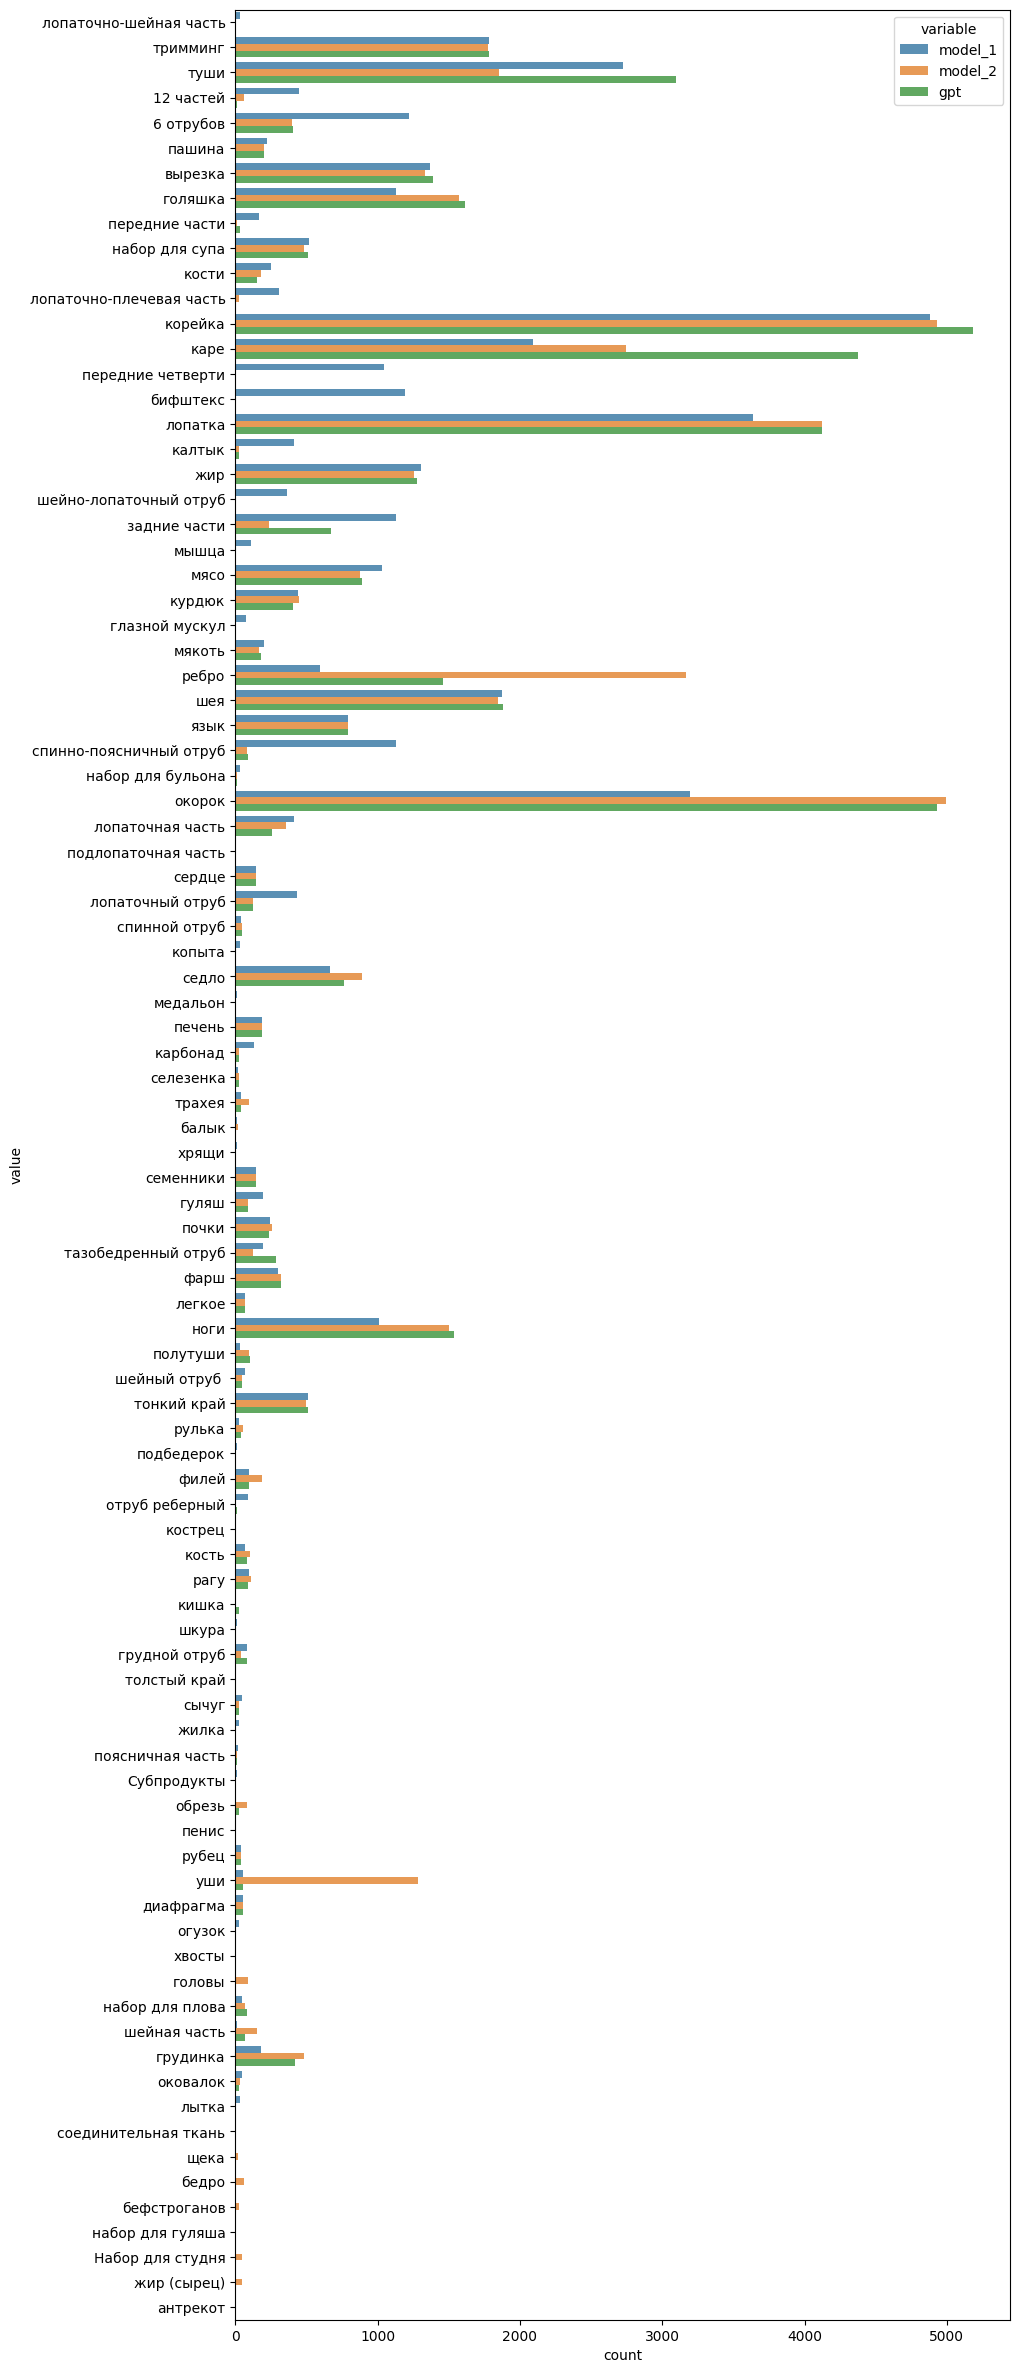

In [11]:
data = mutton_df.melt( value_vars=['model_1', 'model_2', 'gpt'])
plt.figure(figsize=(10, 30))
sns.countplot(y='value', data=data, hue='variable', alpha=0.8)
plt.show()

# Говядина

In [12]:
beef_df = pd.read_csv('data\monitorings_archive\Говядина.csv')
beef_cls_df = pd.read_csv('data\categories\Говядина_разрубы.csv', sep=';')

beef_df = beef_df.rename(columns={'Категория': 'model_1', 'Новая Категория':'model_2', 'Конечная категория':'gpt'})
beef_df['gpt'] = beef_df['gpt'].str.lower()

In [13]:
cls_name = beef_cls_df['value'].unique()
print(f'классов в датасете {len(cls_name)}')

классов в датасете 109


In [14]:
beef_df[['model_1', 'model_2', 'gpt']].describe()

,model_1,model_2,gpt
count,321126,321126,321126
unique,108,106,210
top,мясо,мясо,мясо
freq,49924,46054,46123


In [15]:
model_1_to_2 = len(beef_df[beef_df['model_1'] == beef_df['model_2']])
model_1_to_gpt = len(beef_df[beef_df['model_1'] == beef_df['gpt']])
model_2_to_gpt = len(beef_df[beef_df['model_2'] == beef_df['gpt']])

print(f'Всего объектов: {len(beef_df)}')
print(f'совпадений между 1 и 2 моделью: {model_1_to_2} / {round(model_1_to_2/len(beef_df), 2) * 100}%')
print(f'между 1 и ChatGPT: {model_1_to_gpt} / {round(model_1_to_gpt/len(beef_df), 2) * 100}%')
print(f'между 2 и ChatGPT {model_2_to_gpt} / {round(model_2_to_gpt/len(beef_df), 2) * 100}%')

Всего объектов: 321126
совпадений между 1 и 2 моделью: 271057 / 84.0%
между 1 и ChatGPT: 274198 / 85.0%
между 2 и ChatGPT 307987 / 96.0%


Ошибочные предсказания от GPT

In [16]:
cls_name = beef_cls_df['value'].unique()
gpt_cls = beef_df['gpt'].unique()
wrong_cls = list(set(gpt_cls) - set(cls_name))
wrong_cls

['корейка - это мясо. в данном случае, корейка относится к категории "мякоть".',
 'корейка нк, халяль - мясо',
 'лапы относятся к категории ноги.',
 'корейка - это мясо.',
 'блочная',
 'корейка - шея',
 'робиты бк - это не мясной продукт, поэтому не попадает в указанные категории.',
 'корейка - это мясо, поэтому относится к категории: мясо.',
 'хребты - ребро',
 'котлетка',
 'поясничная часть тонкий относится к категории спинно-поясничный отруб.',
 'корейка с/ф относится к категории "корейка".',
 'ростбиф нк относится к категории: стейк.',
 'корейка 12 ребер нк относится к категории: отруб реберный.',
 'толстый край, тонкий край',
 'сангрия 90% не относится к указанным категориям.',
 'филейный край относится к категории: филей.',
 'корейка',
 'щека.',
 'бескостная',
 'филейный край относится к категории филе.',
 'робиты бк - это не мясной продукт, поэтому не относится ни к одной из указанных категорий.',
 'орейка относится к категории: мясо.',
 'ростбиф нк относится к категории: мякоть

In [17]:
wrrong_preds = len(beef_df[beef_df['gpt'].isin(wrong_cls)])
f'количество ошибочных предсказаний ChatGPT {wrrong_preds}'

'количество ошибочных предсказаний ChatGPT 4691'

In [18]:
beef_df = beef_df.drop(beef_df[beef_df['gpt'].isin(wrong_cls)].index, axis=0)

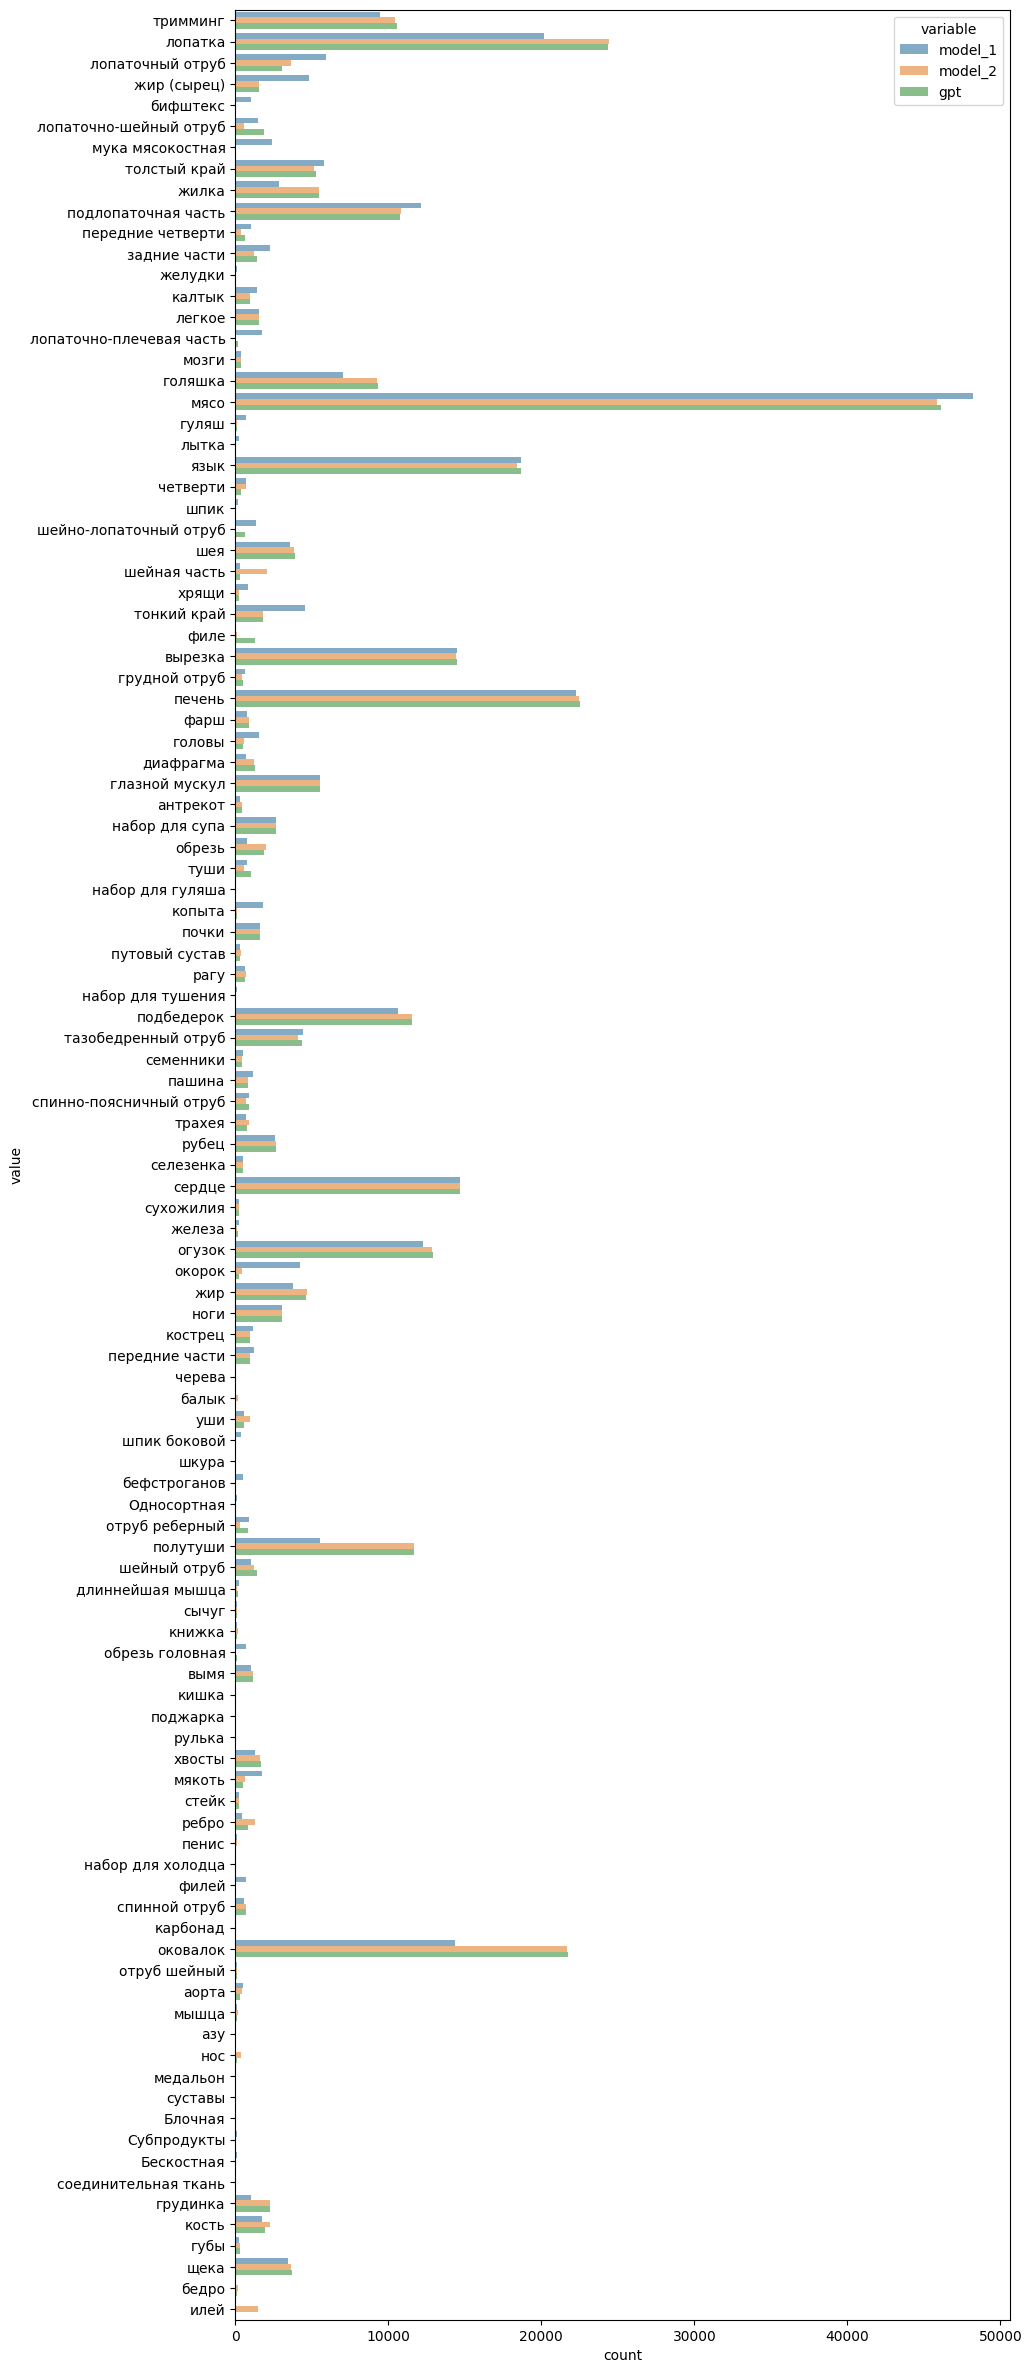

In [19]:
data = beef_df.melt( value_vars=['model_1', 'model_2', 'gpt'])
plt.figure(figsize=(10, 30))
sns.countplot(y='value', data=data, hue='variable', alpha=0.6)
plt.show()

# Свинина

In [20]:
pig_df = pd.read_csv('data\monitorings_archive\Свинина.csv')
pig_cls_df = pd.read_csv('data\categories\Свинина_разрубы.csv', sep=';')

pig_df = pig_df.rename(columns={'Категория': 'model_1', 'Новая Категория':'model_2', 'Конечная категория':'gpt'})
pig_df['gpt'] = pig_df['gpt'].str.lower()

In [21]:
f'всего классов: {len(pig_cls_df["value"])}'

'всего классов: 88'

In [22]:
pig_df[['model_1', 'model_2', 'gpt']].describe()

,model_1,model_2,gpt
count,276774,276774,276774
unique,87,86,129
top,шея,окорок,окорок
freq,19941,26102,25885


In [23]:
model_1_to_2 = len(pig_df[pig_df['model_1'] == pig_df['model_2']])
model_1_to_gpt = len(pig_df[pig_df['model_1'] == pig_df['gpt']])
model_2_to_gpt = len(pig_df[pig_df['model_2'] == pig_df['gpt']])

print(f'Всего объектов: {len(pig_df)}')
print(f'совпадений между 1 и 2 моделью: {model_1_to_2} / {round(model_1_to_2/len(pig_df), 2) * 100}%')
print(f'между 1 и ChatGPT: {model_1_to_gpt} / {round(model_1_to_gpt/len(pig_df), 2) * 100}%')
print(f'между 2 и ChatGPT {model_2_to_gpt} / {round(model_2_to_gpt/len(pig_df), 2) * 100}%')

Всего объектов: 276774
совпадений между 1 и 2 моделью: 210564 / 76.0%
между 1 и ChatGPT: 225151 / 81.0%
между 2 и ChatGPT 256104 / 93.0%


In [24]:
cls_name = pig_cls_df['value'].unique()
gpt_cls = pig_df['gpt'].unique()
wrong_cls = list(set(gpt_cls) - set(cls_name))
wrong_cls

['гузенка упак. относится к категории: задние части.',
 'гузенка упак. относится к категории "задние части".',
 'шн/о полиблок относится к категории "мясо".',
 'шницель относится к категории: котлетные части (котлета).',
 'спинно-поясничный отруб',
 'аорта, трахея',
 'пикало относится к категории: мясо.',
 'шницель натуральный относится к категории мясо.',
 'четвертины',
 'субпродукты',
 'подбедерок относится к категории "задние части".',
 'щека бк без шкуры относится к категории щека.',
 'грудной отруб',
 'щека н/ш относится к категории щека.',
 'щека жилованная относится к категории щека.',
 'шпик.',
 'крыло',
 'пикало',
 'шея, шпик',
 'крыло относится к категории: ноги.',
 'книги',
 'четверти',
 'набор для студня',
 'поросята молочные в/у 3-5 кг относятся к категории: туши.',
 'четвертина',
 'гузенка весовой относится к категории "головы".',
 'сало',
 'бедро без хребта относится к категории: окорок.',
 'отруба',
 'книга',
 'крыло 2 фаланг.,гост - задние части',
 'четвертины относятс

In [25]:
wrrong_preds = len(pig_df[pig_df['gpt'].isin(wrong_cls)])
f'количество ошибочных предсказаний ChatGPT {wrrong_preds}'

'количество ошибочных предсказаний ChatGPT 1047'

In [26]:
pig_df = pig_df.drop(pig_df[pig_df['gpt'].isin(wrong_cls)].index, axis=0)

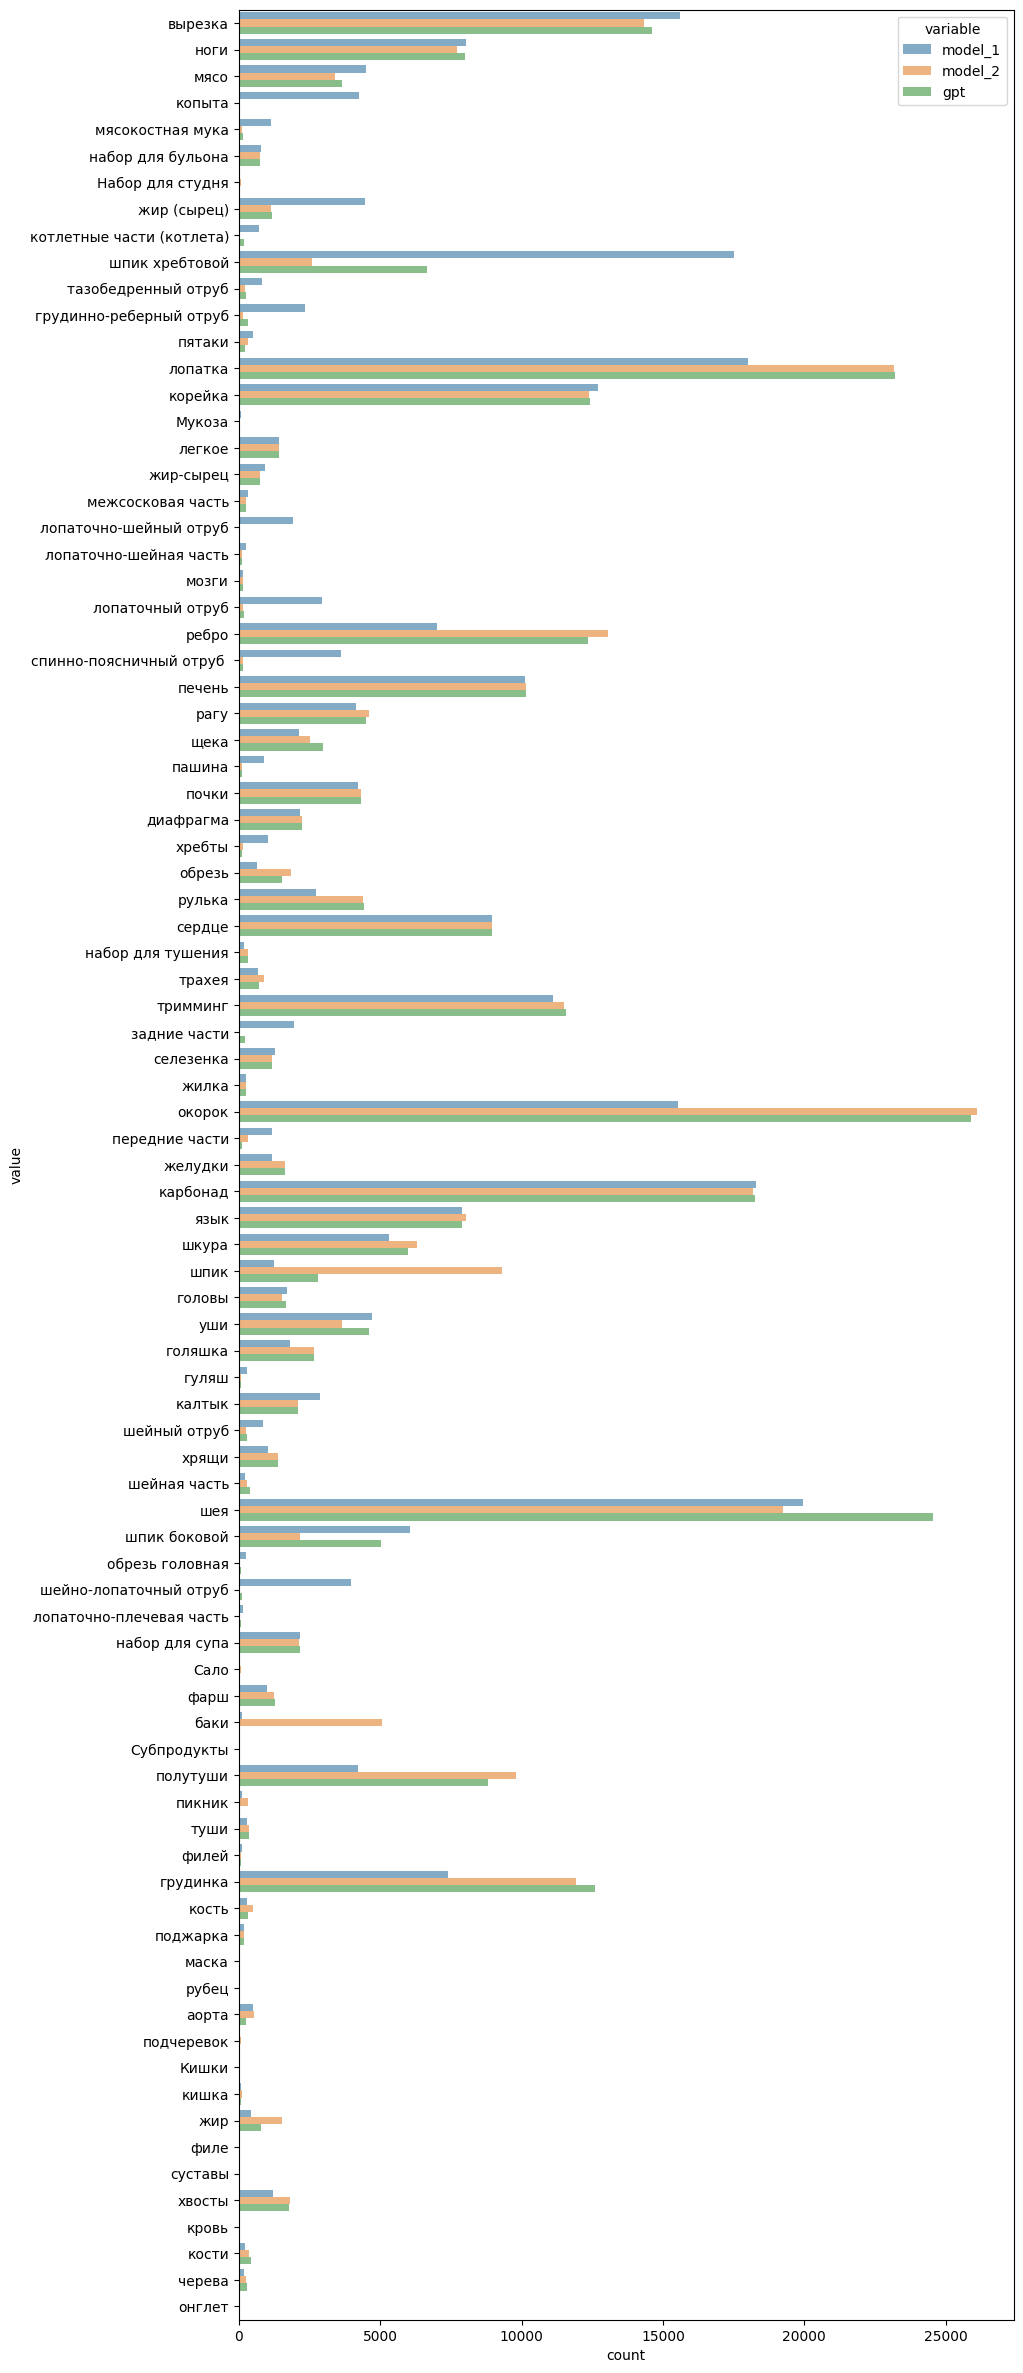

In [27]:
data = pig_df.melt( value_vars=['model_1', 'model_2', 'gpt'])
plt.figure(figsize=(10, 30))
sns.countplot(y='value', data=data, hue='variable', alpha=0.6)
plt.show()

# Птица

Теперь посмотрим на датасет с птицей, где у нас есть только две модели и нет классификации от ChatGPT

In [28]:
bird_df = pd.read_csv('data\monitorings_archive\Птица.csv')
bird_cls_df = pd.read_csv('data\categories\Птица_разрубы.csv', sep=';')

bird_df = bird_df.rename(columns={'Категория': 'model_1', 'Новая Категория':'model_2'})

In [29]:
bird_df.head(1)

,Наименование,Описание,Зам./ Охл.,Страна,Упаковка,Наличие,Партия,Условия поставки,Цена,Компания,Вид деятельности,Телефон,Контактное лицо,E-mail,Дата,federal_okrug,Сорт/Категория,Сертификация,model_1,model_2
0,Индейка,Желудки подл.,зам,Россия,"короб 6,4 кг.",Склад,NaN,Возм. доставка,157.0,ООО РУСКОМ,Производитель,"(495) 640-09-10, (964) 647-23-76",Александр,sale2.moscow@sibkolbasy.ru,2015-01-14,NaN,NaN,NaN,гребешки,желудки


In [30]:
print(f'классов в датасете {bird_cls_df["value"].nunique()}')

классов в датасете 53


In [31]:
bird_df[['model_1', 'model_2']].describe()

,model_1,model_2
count,540013,540013
unique,53,54
top,филе грудки,филе
freq,63946,77729


In [32]:
model_1_to_2 = len(bird_df[bird_df['model_1'] == bird_df['model_2']])

print(f'Всего объектов: {len(bird_df)}')
print(f'совпадений между 1 и 2 моделью: {model_1_to_2} / {round(model_1_to_2/len(bird_df) * 100, 2)}%')

Всего объектов: 540013
совпадений между 1 и 2 моделью: 291504 / 53.98%


Очень низкий процент совпадения между моделями по сравнению с другими мясными направлениями 54% против ~75-80%. Цель написать модели которые будет более близки между собой

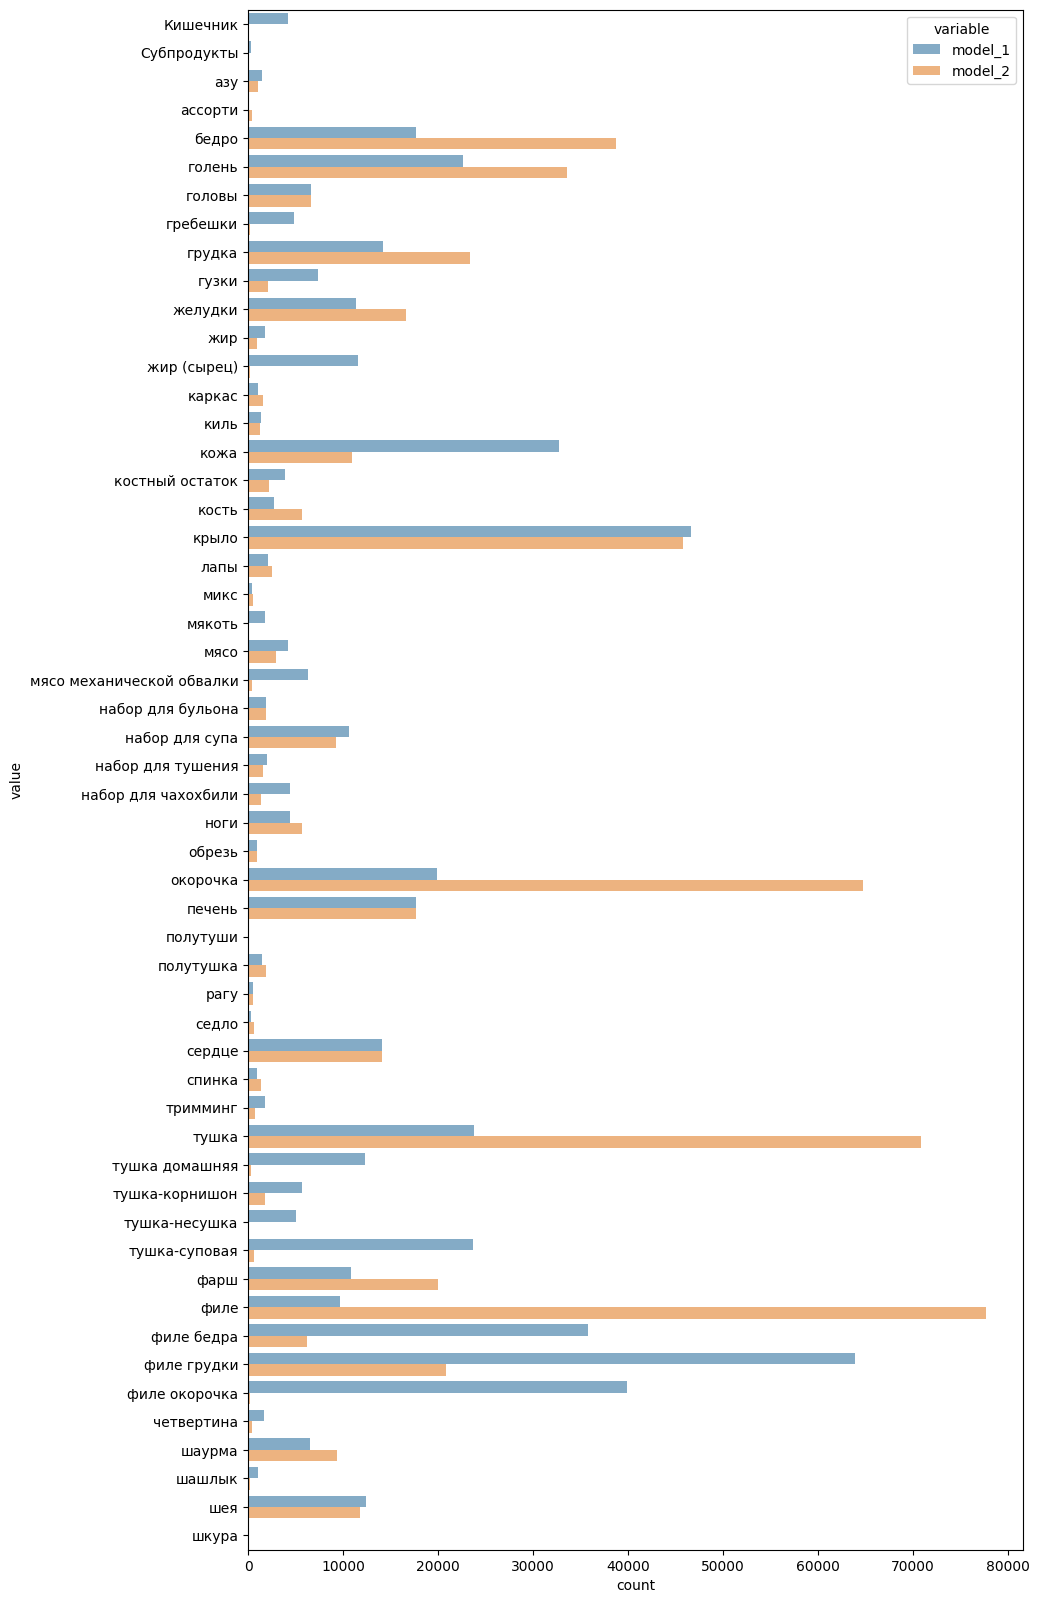

In [33]:
data = bird_df.melt(value_vars=['model_1', 'model_2'])
names = list(data['value'].unique())
names.sort()
plt.figure(figsize=(10, 20))
sns.countplot(y='value', data=data, hue='variable', alpha=0.6, order=names)
plt.show()

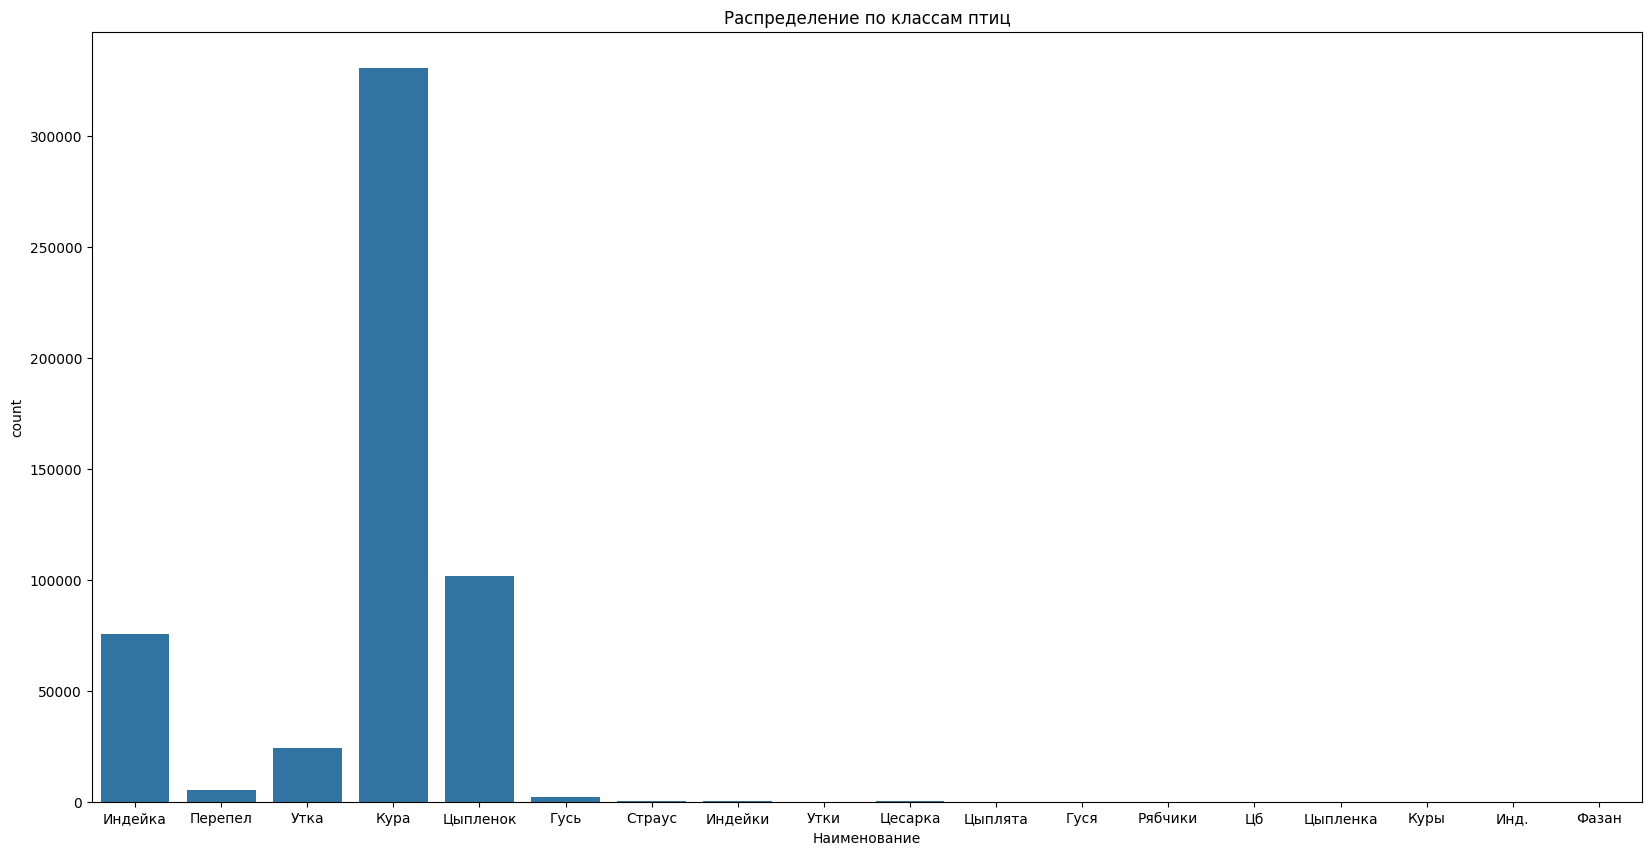

In [34]:
plt.figure(figsize=(20, 10))
sns.countplot(x= bird_df['Наименование'])
plt.title('Распределение по классам птиц')
plt.show()

Варианты по реализации:
Посмотреть в сторону каких-то обычных эвристик без DL и ML, например предобработать входной текст, применить лематизацию или стемминг и определить класс по вхождению слова.

Из плюсов: 
- по идее должен работать быстро, никаких тяжелых подсчетов

Из минусов:
- может быть как плохой так и хороший результат
- никак не учитываем другие признаки которые есть в датасете


Кластеризация на основе табличных данных, классический ML, закодировать текст через tfidf или еще какие-то техники

Из плюсов:
- может быть хороший результат
- не будет дорогих вычислений
- можем учитывать другие признаки

Из минусов:
 - tfidf техника достаточно простая и никак не учитывает порядок слов в предложении их связи и прочее


Какие то DL решения, например использовать предобученную модель семейства bert и получить хорошие эмбеддинги слов, а уже после использовать классический ML

Из плюсов:
- Ожидается самый сильный результат, так как эмбеддинги слов будут лучше отображать суть текстов чем tfidf техника

Из минусов:
- Все минусы DL, обучение моделей, где-то надо будет ее развернуть и прочее
- нужно больше времени на реализацию, чем по сравнению с другими вариантами


Свести задачу к задаче с обучением с учителем. Разметить какие-то количество данных для датасета и обучить любую модельку классификации

Из плюсов:
- Предсказания будут хорошие

Из минусов:
- Не понятно сколько данных нужно размечать, чтобы модель смогла хорошо научиться предсказывать классы
- Время на разметку
- Никто не хочет заниматься разметкой